In [9]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np

ticker = "NVDA"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

data['SMA_5'] = data['Close'].rolling(window=5).mean()
data['SMA_20'] = data['Close'].rolling(window=20).mean()

data['Returns'] = data['Close'].pct_change()

data['Vol_10'] = data['Returns'].rolling(window=10).std()

data.dropna(inplace=True)

print(f"Aperçu des données pour {ticker}:")
print(data[['Close', 'SMA_5', 'Target']].tail())

[*********************100%***********************]  1 of 1 completed

Aperçu des données pour NVDA:
Price           Close      SMA_5 Target
Ticker           NVDA                  
Date                                   
2023-12-22  48.800175  49.092390      1
2023-12-26  49.248894  48.932887      1
2023-12-27  49.386814  48.895512      1
2023-12-28  49.491749  49.177540      0
2023-12-29  49.491749  49.283876      0


In [5]:
!pip install scikit-learn avant

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Sélection des "Features" (ce que l'IA regarde) et de la "Target" (ce qu'elle doit prédire)
features = ['SMA_5', 'SMA_20', 'Returns', 'Vol_10']
X = data[features]
y = data['Target']

# 2. Séparation Entraînement / Test (on garde les 100 derniers jours pour tester)
# En finance, on ne mélange pas les données, on garde les plus récentes pour le test.
train_X, test_X = X[:-100], X[-100:]
train_y, test_y = y[:-100], y[-100:]

# 3. Création et entraînement du modèle
model = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)
model.fit(train_X, train_y)

# 4. Prédiction et mesure de précision
preds = model.predict(test_X)
score = accuracy_score(test_y, preds)

print(f"Précision du modèle : {score * 100:.2f}%")

Précision du modèle : 45.00%


[*********************100%***********************]  1 of 1 completed


--- Rapport de Performance pour NVDA ---
Précision Globale : 50.00%

Détails par classe (0: Baisse, 1: Hausse) :
              precision    recall  f1-score   support

           0       0.47      0.77      0.58       132
           1       0.59      0.28      0.38       160

    accuracy                           0.50       292
   macro avg       0.53      0.52      0.48       292
weighted avg       0.54      0.50      0.47       292



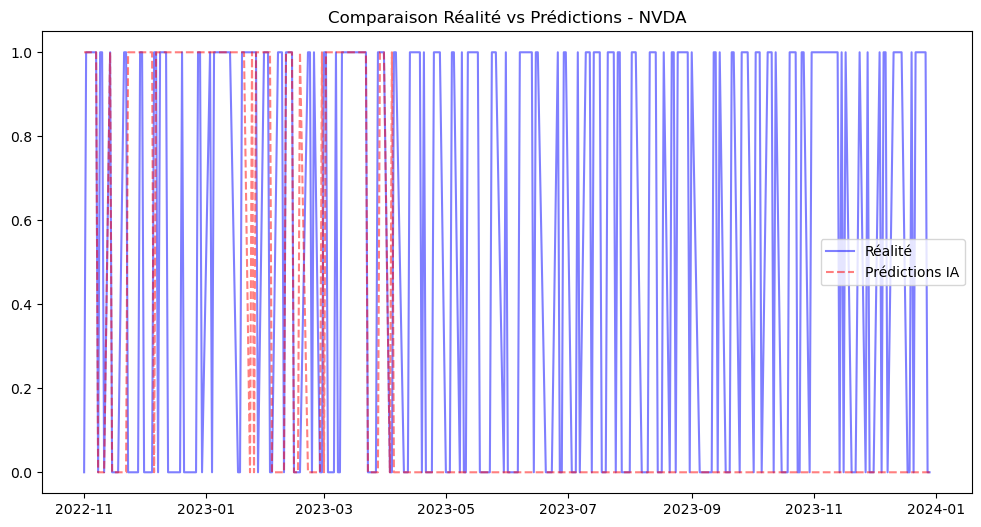

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1. CONFIGURATION ---
TICKER = "NVDA"
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"

# --- 2. COLLECTE & FEATURE ENGINEERING ---
def prepare_data(symbol):
    df = yf.download(symbol, start=START_DATE, end=END_DATE)
    
    # Indicateurs Techniques
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['RSI'] = 100 - (100 / (1 + df['Close'].pct_change().rolling(window=14).mean() / df['Close'].pct_change().rolling(window=14).std()))
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    return df.dropna()

data = prepare_data(TICKER)

# --- 3. ENTRAÎNEMENT DU MODÈLE ---
features = ['SMA_10', 'SMA_50', 'RSI', 'Close']
X = data[features]
y = data['Target']

# Split chronologique (80% train, 20% test)
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)
model.fit(X_train, y_train)

# --- 4. ÉVALUATION & PRÉDICTIONS ---
predictions = model.predict(X_test)
precision = accuracy_score(y_test, predictions)

print(f"--- Rapport de Performance pour {TICKER} ---")
print(f"Précision Globale : {precision:.2%}")
print("\nDétails par classe (0: Baisse, 1: Hausse) :")
print(classification_report(y_test, predictions))

# --- 5. VISUALISATION DES RÉSULTATS ---
plt.figure(figsize=(12, 6))
plt.plot(data.index[split:], y_test.values, label="Réalité", alpha=0.5, color='blue')
plt.plot(data.index[split:], predictions, label="Prédictions IA", alpha=0.5, color='red', linestyle='--')
plt.title(f"Comparaison Réalité vs Prédictions - {TICKER}")
plt.legend()
plt.show()

In [7]:
# 1. Calcul des rendements réels sur la période de test
test_data = data.iloc[split:].copy()
test_data['Preds'] = predictions

# 2. Calcul du rendement de la stratégie
# Si Preds == 1, on gagne (ou perd) le rendement du jour suivant
test_data['Strategy_Returns'] = test_data['Preds'] * test_data['Returns'].shift(-1)

# 3. Calcul du rendement cumulé (Base 100)
test_data['Cumulative_Market'] = (1 + test_data['Returns']).cumprod()
test_data['Cumulative_Strategy'] = (1 + test_data['Strategy_Returns'].fillna(0)).cumprod()

# 4. Affichage des résultats financiers
print(f"--- Performance Financière sur la période de Test ---")
final_market = (test_data['Cumulative_Market'].iloc[-1] - 1) * 100
final_strat = (test_data['Cumulative_Strategy'].iloc[-1] - 1) * 100

print(f"Rendement du Marché (Buy & Hold) : {final_market:.2f}%")
print(f"Rendement de votre IA : {final_strat:.2f}%")

# 5. Graphique de performance
plt.figure(figsize=(12, 6))
plt.plot(test_data['Cumulative_Market'], label="Marché (Apple)", color='gray', alpha=0.7)
plt.plot(test_data['Cumulative_Strategy'], label="Stratégie IA", color='green', linewidth=2)
plt.title("Performance Financière : IA vs Marché")
plt.ylabel("Multiplicateur de Capital")
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'Returns'

--- Résultat Final ---
Rendement du Marché : 265.92%
Rendement de l'IA   : 64.00%


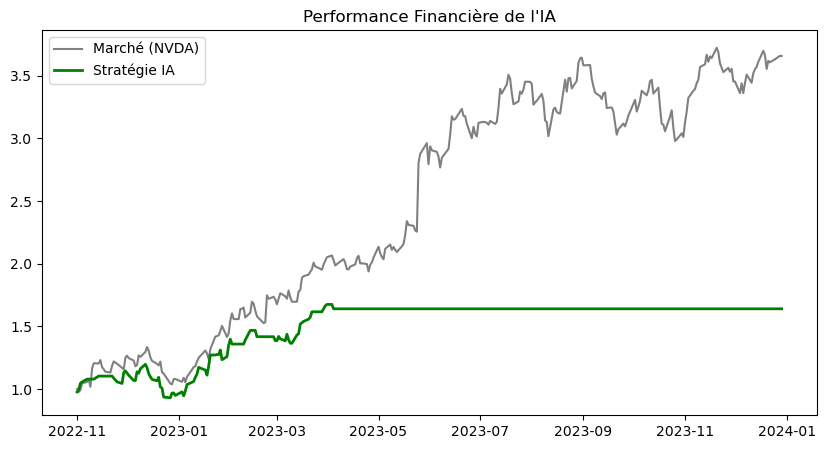

In [11]:
# --- ÉTAPE 4 : CALCUL DU PROFIT (Version Corrigée) ---

# 1. On s'assure d'avoir les données de test
test_data = data.iloc[split:].copy()
test_data['Preds'] = predictions

# 2. On recalcule les rendements (Returns) au cas où ils manqueraient
# Rendement = (Prix du jour / Prix de la veille) - 1
test_data['Returns'] = test_data['Close'].pct_change()

# 3. Calcul du rendement de la stratégie
# On multiplie notre prédiction (0 ou 1) par le rendement du lendemain
test_data['Strategy_Returns'] = test_data['Preds'] * test_data['Returns'].shift(-1)

# 4. Calcul du rendement cumulé (on part de 1)
test_data['Cumulative_Market'] = (1 + test_data['Returns'].fillna(0)).cumprod()
test_data['Cumulative_Strategy'] = (1 + test_data['Strategy_Returns'].fillna(0)).cumprod()

# 5. Affichage des résultats
final_market = (test_data['Cumulative_Market'].iloc[-1] - 1) * 100
final_strat = (test_data['Cumulative_Strategy'].iloc[-1] - 1) * 100

print(f"--- Résultat Final ---")
print(f"Rendement du Marché : {final_market:.2f}%")
print(f"Rendement de l'IA   : {final_strat:.2f}%")

# 6. Graphique
plt.figure(figsize=(10, 5))
plt.plot(test_data['Cumulative_Market'], label="Marché (NVDA)", color='gray')
plt.plot(test_data['Cumulative_Strategy'], label="Stratégie IA", color='green', linewidth=2)
plt.legend()
plt.title("Performance Financière de l'IA")
plt.show()

In [12]:
# --- ÉTAPE 5 : PRÉDICTION EN TEMPS RÉEL (LIVE) ---

# 1. Récupérer les données les plus récentes (jusqu'à aujourd'hui)
live_data = yf.download(TICKER, period="2y")

# 2. Recréer les indicateurs pour le dernier jour disponible
live_data['SMA_10'] = live_data['Close'].rolling(window=10).mean()
live_data['SMA_50'] = live_data['Close'].rolling(window=50).mean()
live_data['RSI'] = 100 - (100 / (1 + live_data['Close'].pct_change().rolling(window=14).mean() / live_data['Close'].pct_change().rolling(window=14).std()))
live_data['Returns'] = live_data['Close'].pct_change()

# 3. Extraire la dernière ligne (Aujourd'hui)
latest_row = live_data[features].iloc[-1:].fillna(0)

# 4. Prédire la direction et la PROBABILITÉ
prediction = model.predict(latest_row)[0]
probability = model.predict_proba(latest_row)[0] # Donne la confiance du modèle

# --- AFFICHAGE DES CONSEILS ---
print(f"\n=== ANALYSE LIVE POUR {TICKER} (PROCHAINE SÉANCE) ===")
if prediction == 1:
    print(f"SIGNAL : 🟢 ACHAT (Hausse prévue)")
    print(f"CONFIANCE : {probability[1]:.2%}")
else:
    print(f"SIGNAL : 🔴 VENTE / ATTENTE (Baisse prévue)")
    print(f"CONFIANCE : {probability[0]:.2%}")

print(f"PRIX ACTUEL : {live_data['Close'].iloc[-1]:.2f}$")

[*********************100%***********************]  1 of 1 completed


=== ANALYSE LIVE POUR NVDA (PROCHAINE SÉANCE) ===
SIGNAL : 🔴 VENTE / ATTENTE (Baisse prévue)
CONFIANCE : 79.53%


TypeError: unsupported format string passed to Series.__format__

In [13]:
# --- ÉTAPE 5 : PRÉDICTION EN TEMPS RÉEL (CORRIGÉE) ---

# 1. On s'assure d'extraire la valeur numérique pure avec .item() ou float()
prix_actuel = float(live_data['Close'].iloc[-1])

# --- AFFICHAGE DES CONSEILS ---
print(f"\n=== ANALYSE LIVE POUR {TICKER} (PROCHAINE SÉANCE) ===")
if prediction == 1:
    print(f"SIGNAL : 🟢 ACHAT (Hausse prévue)")
    print(f"CONFIANCE : {probability[1]:.2%}")
else:
    print(f"SIGNAL : 🔴 VENTE / ATTENTE (Baisse prévue)")
    print(f"CONFIANCE : {probability[0]:.2%}")

print(f"PRIX ACTUEL : {prix_actuel:.2f}$")

# CONSEIL STRATÉGIQUE
if probability.max() > 0.60:
    print("\nAVIS EXPERT : Signal à haute probabilité. Prudence recommandée.")
else:
    print("\nAVIS EXPERT : Signal faible. Le marché hésite.")


=== ANALYSE LIVE POUR NVDA (PROCHAINE SÉANCE) ===
SIGNAL : 🔴 VENTE / ATTENTE (Baisse prévue)
CONFIANCE : 79.53%
PRIX ACTUEL : 175.87$

AVIS EXPERT : Signal à haute probabilité. Prudence recommandée.


C:\Users\DELL\AppData\Local\Temp\ipykernel_6700\846785988.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(live_data['Close'].iloc[-1])


In [14]:
import yfinance as yf
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# --- 1. LISTE DE SURVEILLANCE (MODIFIABLE) ---
watchlist = ["AAPL", "NVDA", "TSLA", "BTC-USD", "MC.PA"] # Apple, Nvidia, Tesla, Bitcoin, LVMH
resultats = []

print("🚀 Lancement du Scanner de Marché... Patientez quelques secondes.")

for ticker in watchlist:
    try:
        # --- 2. RÉCUPÉRATION & PRÉPARATION ---
        df = yf.download(ticker, start="2020-01-01", progress=False)
        
        # Indicateurs Techniques
        df['SMA_10'] = df['Close'].rolling(window=10).mean()
        df['SMA_50'] = df['Close'].rolling(window=50).mean()
        df['Returns'] = df['Close'].pct_change()
        df['RSI'] = 100 - (100 / (1 + df['Returns'].rolling(window=14).mean() / df['Returns'].rolling(window=14).std()))
        df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
        df.dropna(inplace=True)

        # --- 3. ENTRAÎNEMENT ÉCLAIR ---
        features = ['SMA_10', 'SMA_50', 'RSI', 'Close']
        X = df[features]
        y = df['Target']
        
        # On entraîne sur tout sauf le dernier jour pour prédire demain
        model = RandomForestClassifier(n_estimators=100, random_state=1)
        model.fit(X[:-1], y[:-1])

        # --- 4. PRÉDICTION LIVE ---
        last_row = X.iloc[-1:]
        prediction = model.predict(last_row)[0]
        prob = model.predict_proba(last_row)[0]
        prix = float(df['Close'].iloc[-1])

        # --- 5. STOCKAGE DES RÉSULTATS ---
        signal = "🟢 ACHAT" if prediction == 1 else "🔴 VENTE"
        confiance = prob[1] if prediction == 1 else prob[0]
        
        resultats.append({
            "Action": ticker,
            "Prix Actuel": f"{prix:.2f}$",
            "Signal": signal,
            "Confiance": f"{confiance:.2%}"
        })
    except:
        print(f"⚠️ Erreur lors de l'analyse de {ticker}")

# --- 6. AFFICHAGE DU DASHBOARD FINAL ---
df_final = pd.DataFrame(resultats)
print("\n" + "="*50)
print("📊 TABLEAU DE BORD DES PRÉDICTIONS")
print("="*50)
print(df_final.to_string(index=False))
print("="*50)

🚀 Lancement du Scanner de Marché... Patientez quelques secondes.


C:\Users\DELL\AppData\Local\Temp\ipykernel_6700\3985641849.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix = float(df['Close'].iloc[-1])
C:\Users\DELL\AppData\Local\Temp\ipykernel_6700\3985641849.py:19: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Returns'] = df['Close'].pct_change()
C:\Users\DELL\AppData\Local\Temp\ipykernel_6700\3985641849.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix = float(df['Close'].iloc[-1])
C:\Users\DELL\AppData\Local\Temp\ipykernel_6700\3985641849.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a 


📊 TABLEAU DE BORD DES PRÉDICTIONS
 Action Prix Actuel  Signal Confiance
   AAPL     248.20$ 🔴 VENTE    63.00%
   NVDA     178.56$ 🟢 ACHAT    65.00%
   TSLA     373.21$ 🔴 VENTE    77.00%
BTC-USD   70062.01$ 🟢 ACHAT    70.00%
  MC.PA     456.95$ 🟢 ACHAT    54.00%


C:\Users\DELL\AppData\Local\Temp\ipykernel_6700\3985641849.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix = float(df['Close'].iloc[-1])


In [16]:
!pip install openpyxl

import datetime

# --- 7. EXPORT VERS EXCEL AVEC HORODATAGE ---
nom_fichier = "predictions_bourse.xlsx"
date_aujourdhui = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")

# Ajout de la date dans le tableau pour le suivi
df_final['Date_Analyse'] = date_aujourdhui

try:
    # On essaie de lire le fichier s'il existe déjà pour ajouter les nouvelles lignes
    try:
        existant = pd.read_excel(nom_fichier)
        df_complet = pd.concat([existant, df_final], ignore_index=True)
    except FileNotFoundError:
        df_complet = df_final

    # Sauvegarde dans le fichier Excel
    df_complet.to_excel(nom_fichier, index=False)
    print(f"\n✅ Historique mis à jour dans : {nom_fichier}")
    
except Exception as e:
    print(f"\n⚠️ Erreur lors de l'enregistrement Excel : {e}")
    print("Conseil : Vérifiez que le fichier Excel n'est pas déjà ouvert sur votre ordinateur.")


✅ Historique mis à jour dans : predictions_bourse.xlsx
